# HW2: 基于 ReLU 网络的函数拟合（PyTorch）


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cpu


## 1. 函数定义

这里定义目标函数：

$f(x)=\sin(2.5x)+0.2x^3-0.3x$


In [2]:
def target_function(x: np.ndarray) -> np.ndarray:
    return np.sin(2.5 * x) + 0.2 * x ** 3 - 0.3 * x

# 2. 数据采样
n_train = 600
n_test = 200
x_low, x_high = -3.0, 3.0

x_train = np.random.uniform(x_low, x_high, size=(n_train, 1)).astype(np.float32)
y_train_clean = target_function(x_train).astype(np.float32)
noise = np.random.normal(0.0, 0.05, size=y_train_clean.shape).astype(np.float32)
y_train = y_train_clean + noise

x_test = np.linspace(x_low, x_high, n_test, dtype=np.float32).reshape(-1, 1)
y_test = target_function(x_test).astype(np.float32)

x_train_t = torch.from_numpy(x_train)
y_train_t = torch.from_numpy(y_train)
x_test_t = torch.from_numpy(x_test)
y_test_t = torch.from_numpy(y_test)

train_loader = DataLoader(
    TensorDataset(x_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

print('Train set:', x_train_t.shape, y_train_t.shape)
print('Test set :', x_test_t.shape, y_test_t.shape)


Train set: torch.Size([600, 1]) torch.Size([600, 1])
Test set : torch.Size([200, 1]) torch.Size([200, 1])


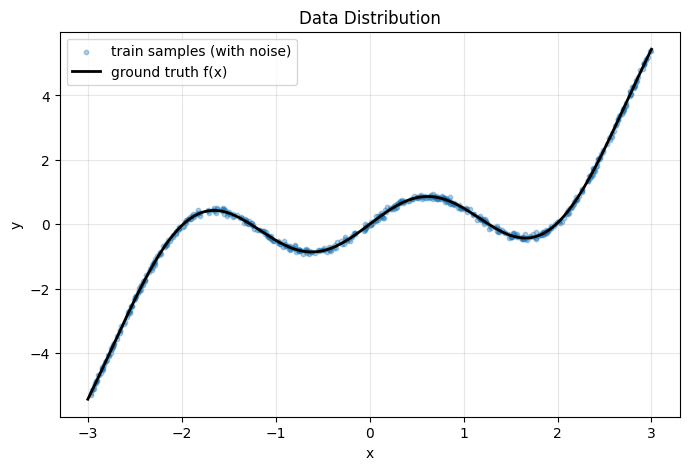

In [3]:
# 训练/测试数据分布可视化
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, s=10, alpha=0.35, label='train samples (with noise)')
plt.plot(x_test, y_test, color='black', linewidth=2, label='ground truth f(x)')
plt.title('Data Distribution')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. 模型描述

使用一个两层 ReLU 隐藏层的前馈网络：

- 输入维度：1
- 隐藏层：128 -> ReLU -> 128 -> ReLU
- 输出维度：1

损失函数采用 MSELoss，优化器采用 Adam。


In [4]:
class ReLURegressor(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ReLURegressor(hidden_dim=128).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

model


ReLURegressor(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [5]:
# 训练
num_epochs = 2000
loss_history = []

model.train()
for epoch in range(1, num_epochs + 1):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)

    if epoch % 200 == 0 or epoch == 1:
        print(f'Epoch [{epoch:4d}/{num_epochs}], Train MSE: {epoch_loss:.6f}')


Epoch [   1/2000], Train MSE: 2.412132
Epoch [ 200/2000], Train MSE: 0.002749
Epoch [ 400/2000], Train MSE: 0.004502
Epoch [ 600/2000], Train MSE: 0.002804
Epoch [ 800/2000], Train MSE: 0.002836
Epoch [1000/2000], Train MSE: 0.003237
Epoch [1200/2000], Train MSE: 0.002803
Epoch [1400/2000], Train MSE: 0.002926
Epoch [1600/2000], Train MSE: 0.003091
Epoch [1800/2000], Train MSE: 0.002466
Epoch [2000/2000], Train MSE: 0.004256


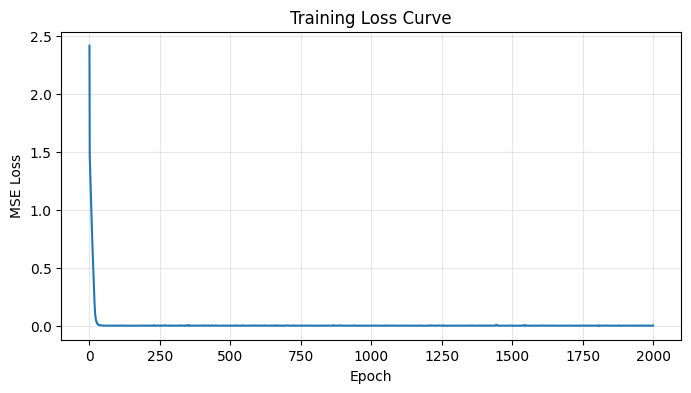

In [6]:
# 训练过程损失曲线
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.show()


Test MSE: 0.002101
Test MAE: 0.034276


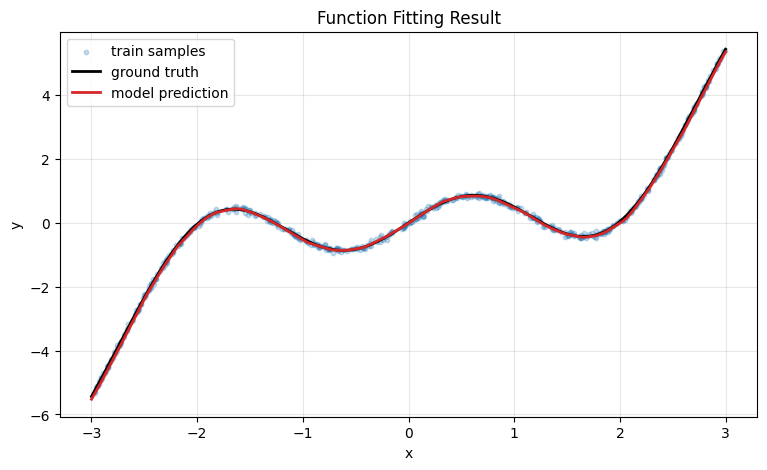

In [7]:
# 4. 测试集评估 + 拟合效果可视化
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test_t.to(device)).cpu()

test_mse = criterion(y_pred_test, y_test_t).item()
test_mae = torch.mean(torch.abs(y_pred_test - y_test_t)).item()
print(f'Test MSE: {test_mse:.6f}')
print(f'Test MAE: {test_mae:.6f}')

plt.figure(figsize=(9, 5))
plt.scatter(x_train, y_train, s=10, alpha=0.25, label='train samples')
plt.plot(x_test, y_test, color='black', linewidth=2, label='ground truth')
plt.plot(x_test, y_pred_test.numpy(), color='tab:red', linewidth=2, label='model prediction')
plt.title('Function Fitting Result')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
